In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Hand-crafted

In [2]:
def generate_handcrafted_metrics(pattern="../res/handcrafted/handcrafted_*.csv"):
    all_summaries = []
    files = glob.glob(pattern)
    
    if not files:
        print("No files found. Check if you are in the correct directory.")
        return

    for f in files:
        # Extract Test and Policy from filename
        # Assumes: handcrafted_testname_policyname.csv
        parts = os.path.basename(f).replace('.csv', '').split('_')
        if len(parts) < 3:
            continue
            
        test_name = parts[1]
        policy_name = parts[2]
        
        # Load data
        df = pd.read_csv(f)
        
        # 1. Sum up all operations (Duration_Sec) for each unique RequestID
        # This gives us the total time a user waited for that specific request
        total_latencies = df.groupby('RequestID')['Duration_Sec'].sum()
        
        # 2. Calculate Statistics
        metrics = {
            'Scenario': test_name,
            'Policy': policy_name,
            # 'Total Latency': total_latencies.sum(),
            'Median (s)': total_latencies.median(),
            'P90 (s)': total_latencies.quantile(0.90),
            'P99 (s)': total_latencies.quantile(0.99),
            'Average Latency (s)': total_latencies.mean(),
            'Sample Size': len(total_latencies)
        }
        all_summaries.append(metrics)

    # Create a clean DataFrame
    summary_df = pd.DataFrame(all_summaries)
    
    # Sort for better readability
    summary_df = summary_df.sort_values(by=['Scenario', 'Policy'])
    
    # Round to 3 decimal places for the report
    return summary_df.round(3)

# Execute and display
metrics_table = generate_handcrafted_metrics()
print(metrics_table.to_string(index=False))

             Scenario    Policy  Median (s)  P90 (s)  P99 (s)  Average Latency (s)  Sample Size
          1-evic-4w2m      FIFO      21.851   22.101   22.158               14.950            3
          1-evic-4w2m Immediate      21.851   21.852   21.852               21.852            3
          1-evic-4w2m      LFRU      21.851   22.101   22.158               14.950            3
          1-evic-4w2m       LFU      21.851   22.101   22.158               14.950            3
          1-evic-4w2m      LIFO      21.851   22.101   22.158               14.950            3
          1-evic-4w2m       LRU      21.851   22.101   22.158               14.950            3
          1-evic-4w2m       MRU      21.851   22.101   22.158               14.950            3
          1-evic-4w2m        RR      21.851   22.101   22.158               14.950            3
       2-no-evic-4w1m      FIFO       0.209    7.133    8.691                3.094            3
       2-no-evic-4w1m Immediate       8.

# Real Life

In [5]:
def plot_benchmark_distributions_multi_run(pattern="../res/real_life/bench_*_iter*.csv", zoo_size=40):
    files = glob.glob(pattern)
    if not files: return

    # Structure: { Distribution: { Mode: [Data] } }
    dist_data = {}
    
    for f in files:
        parts = os.path.basename(f).replace('.csv', '').split('_')
        # Matching your Go naming: [0]bench, [1]policy, [2]dist, [3]mode, [4]cID, [5]iter
        dist_type = parts[2]
        mode = parts[3] 
        
        df = pd.read_csv(f)
        # Unique RequestIDs to count how many times each model was 'targeted'
        counts = df.groupby('ModelID')['RequestID'].nunique().sort_values(ascending=False).values
        
        padded_counts = np.zeros(zoo_size)
        padded_counts[:len(counts)] = counts
        
        if dist_type not in dist_data:
            dist_data[dist_type] = {"Single": [], "Multi": []}
        dist_data[dist_type][mode].append(padded_counts)

    sorted_dists = sorted(dist_data.keys())
    fig, axes = plt.subplots(len(sorted_dists), 2, figsize=(14, 4 * len(sorted_dists)))

    for i, dist in enumerate(sorted_dists):
        for j, mode in enumerate(["Single", "Multi"]):
            if not dist_data[dist][mode]: continue
            
            all_runs = np.array(dist_data[dist][mode])
            avg_counts = np.mean(all_runs, axis=0)
            std_counts = np.std(all_runs, axis=0)
            
            axes[i, j].bar(range(zoo_size), avg_counts, yerr=std_counts, capsize=4, 
                           color='teal' if mode=="Single" else 'coral', alpha=0.7)
            axes[i, j].set_title(f"{dist} Profile: {mode}")
            axes[i, j].set_ylabel("Avg Intent Frequency")

    plt.tight_layout()
    plt.show()

# Run with your zoo size (10 models)
plot_benchmark_distributions_multi_run(zoo_size=10)

ValueError: could not broadcast input array from shape (13,) into shape (10,)

In [6]:
def generate_representative_scores(pattern="../res/real_life/bench_*_iter*.csv"):
    all_data = []
    files = glob.glob(pattern)
    
    for f in files:
        parts = os.path.basename(f).replace('.csv', '').split('_')
        policy, dist, mode = parts[1], parts[2], parts[3]

        df = pd.read_csv(f)
        # Sum durations by RequestID to get the TOTAL latency of the 'Intent'
        # In a pipeline, the user waits for ALL models to load.
        total_latencies = df.groupby('RequestID')['Duration_Sec'].sum()
        
        all_data.append({
            'Mode': mode,
            'Policy': policy,
            'Distribution': dist,
            'Median_Lat': total_latencies.median(),
            'P90_Lat': total_latencies.quantile(0.90),
            'P99_Lat': total_latencies.quantile(0.99)
        })

    results_df = pd.DataFrame(all_data)

    print("--- Mean Median Latency Comparison ---")
    summary_median = results_df.groupby(['Mode', 'Distribution', 'Policy'])['Median_Lat'].mean().unstack('Policy')
    print(summary_median.round(3))

    print("--- Mean P90 Latency Comparison ---")
    summary_p90 = results_df.groupby(['Mode', 'Distribution', 'Policy'])['P90_Lat'].mean().unstack('Policy')
    print(summary_p90.round(3))

    print("--- Mean P99 Latency Comparison ---")
    summary_p99 = results_df.groupby(['Mode', 'Distribution', 'Policy'])['P99_Lat'].mean().unstack('Policy')
    print(summary_p99.round(3))

# When you print it:
generate_representative_scores()

--- Mean Median Latency Comparison ---
Policy                   FIFO   Immediate        LFU       LIFO       LRU  \
Mode   Distribution                                                         
Multi  Gamma         3117.724    2804.907      7.402   2793.894     2.125   
       Normal        2697.856   10273.604   2606.648      4.266  2462.339   
       Poisson       7225.789    7023.372      2.876      1.825  2707.185   
       PowerLaw         2.086       0.521   9653.687      0.569     2.354   
       Uniform          8.516  115774.894  14056.278      6.899     6.818   
Single Gamma           35.565   74329.409     35.344     34.404    33.988   
       Normal          39.819   73923.122     26.675     31.753    40.593   
       Poisson         37.272   71272.980     34.160  23535.001    38.412   
       PowerLaw        35.459   72014.721  13253.257     23.470    36.246   
       Uniform         41.523   74324.076     19.872     42.730    44.062   

Policy                     MRU      

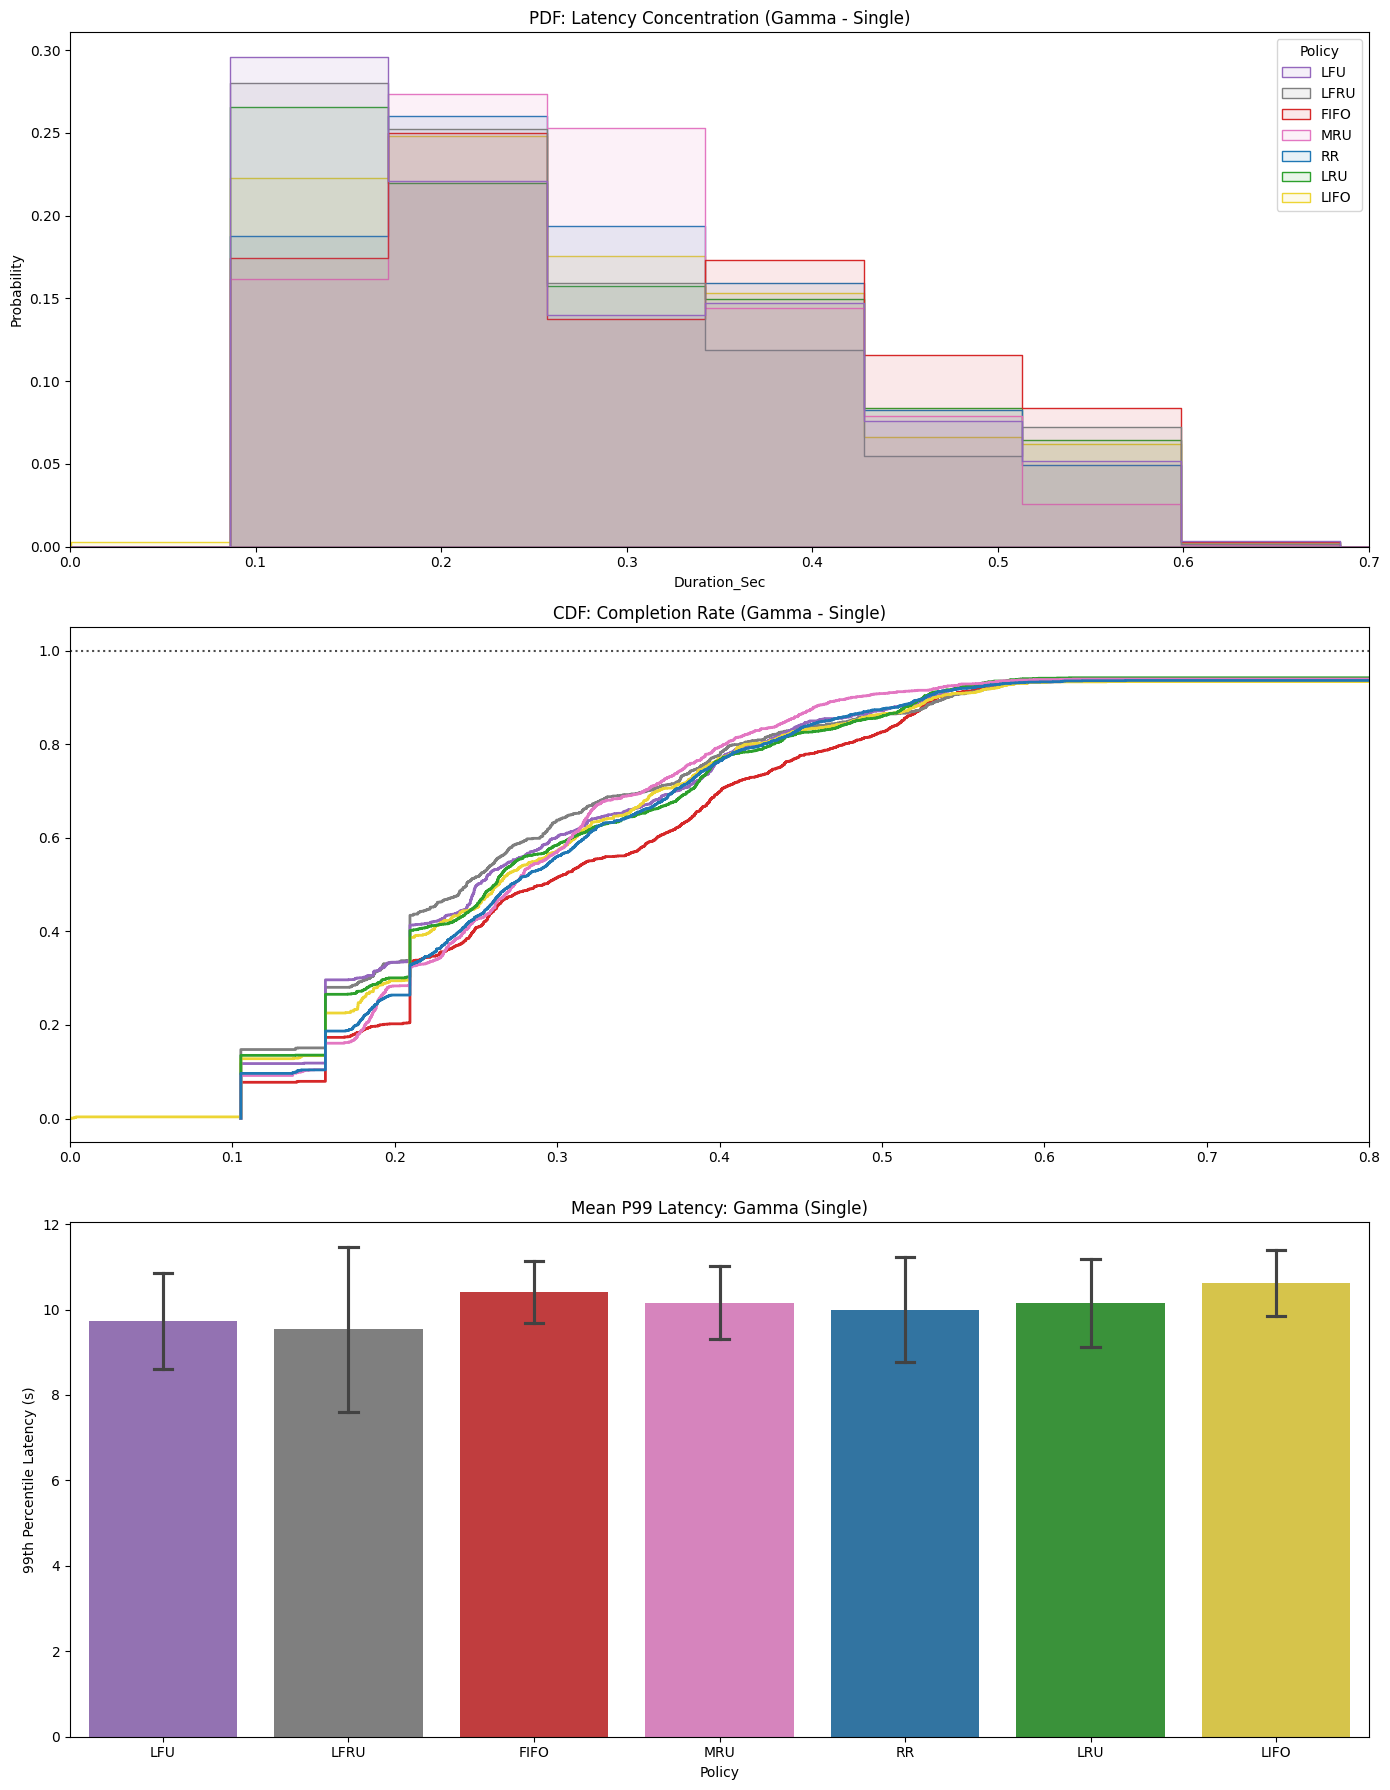

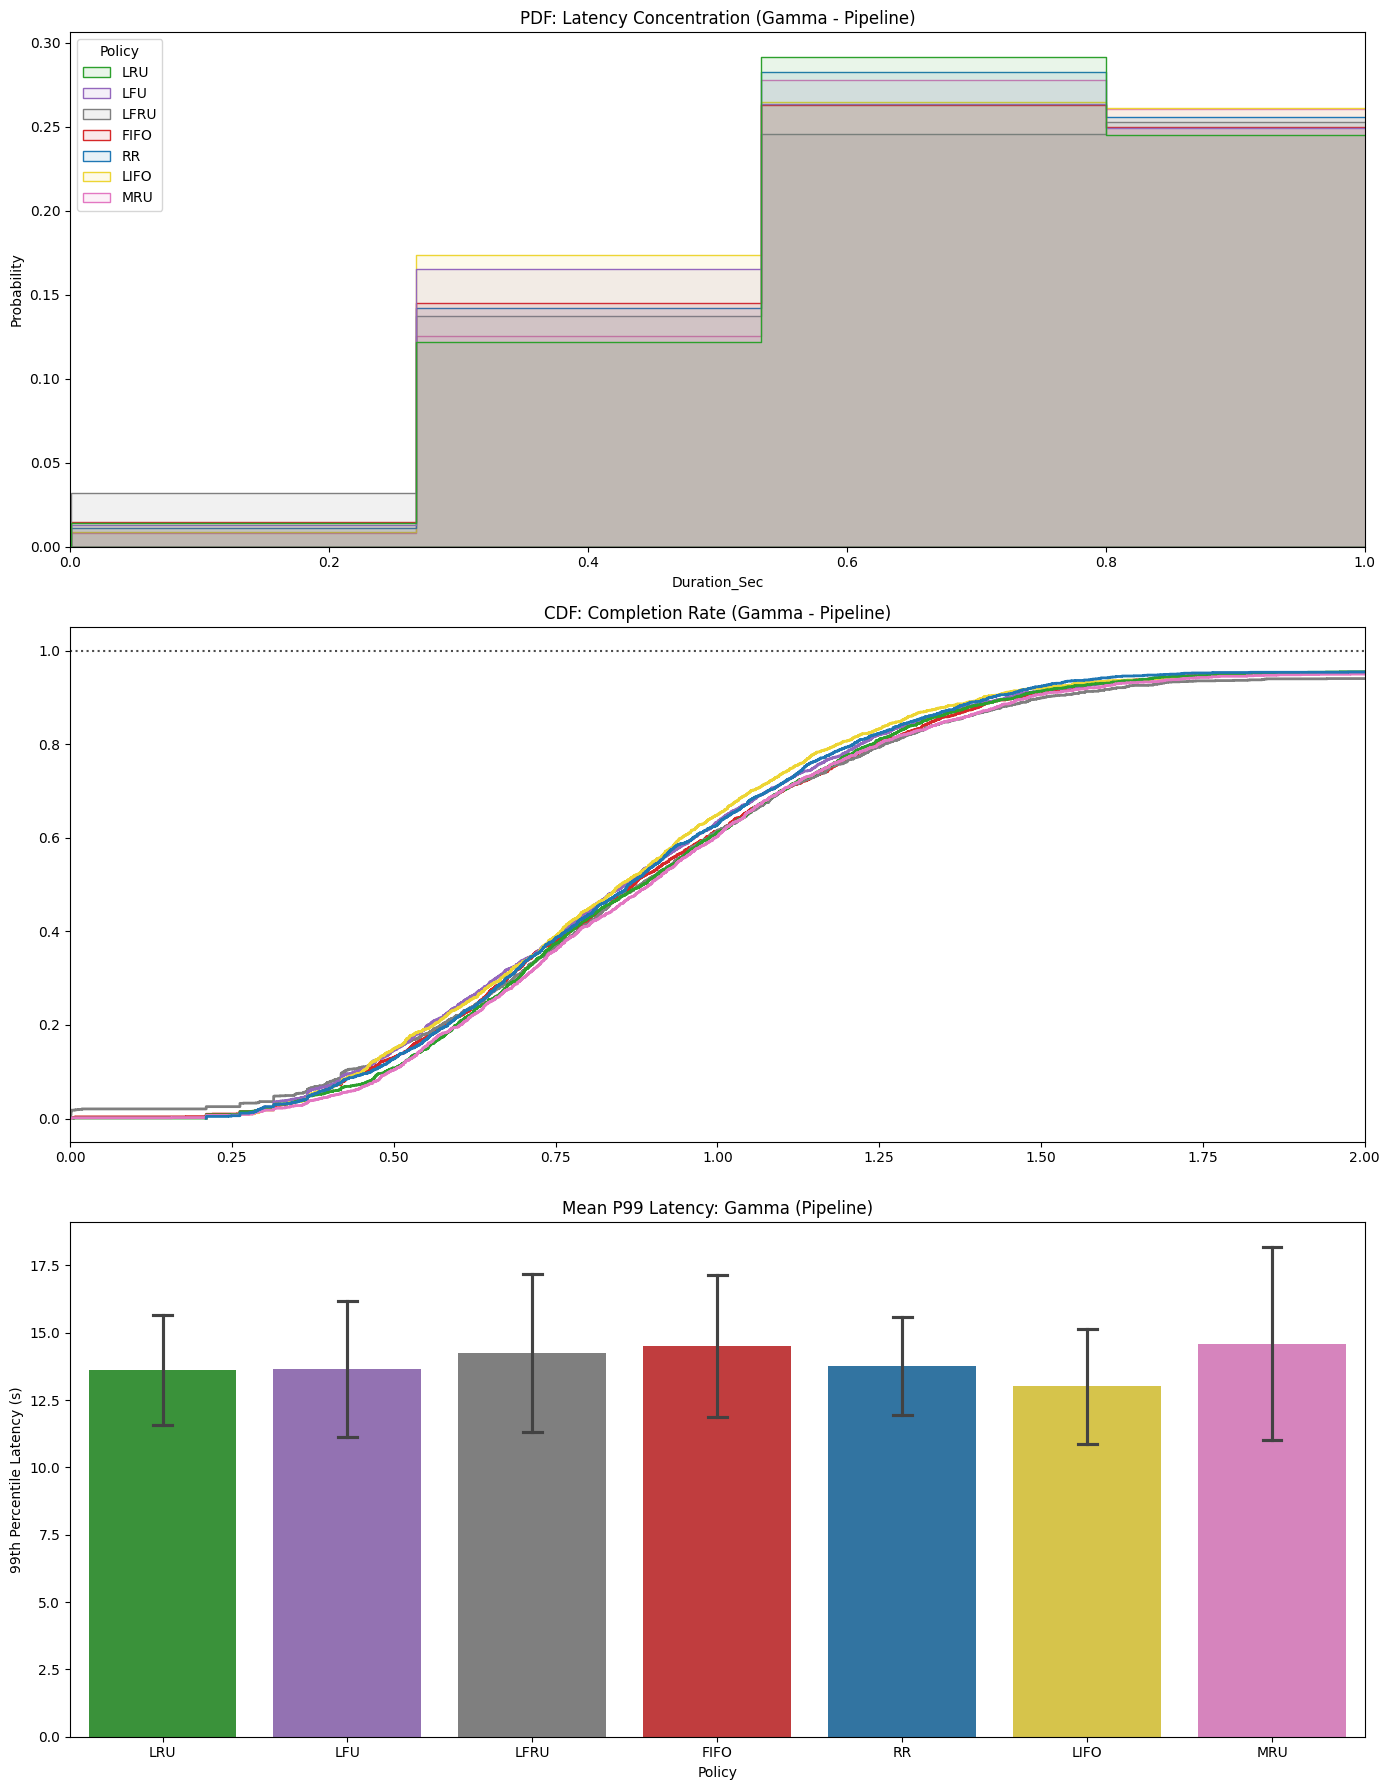

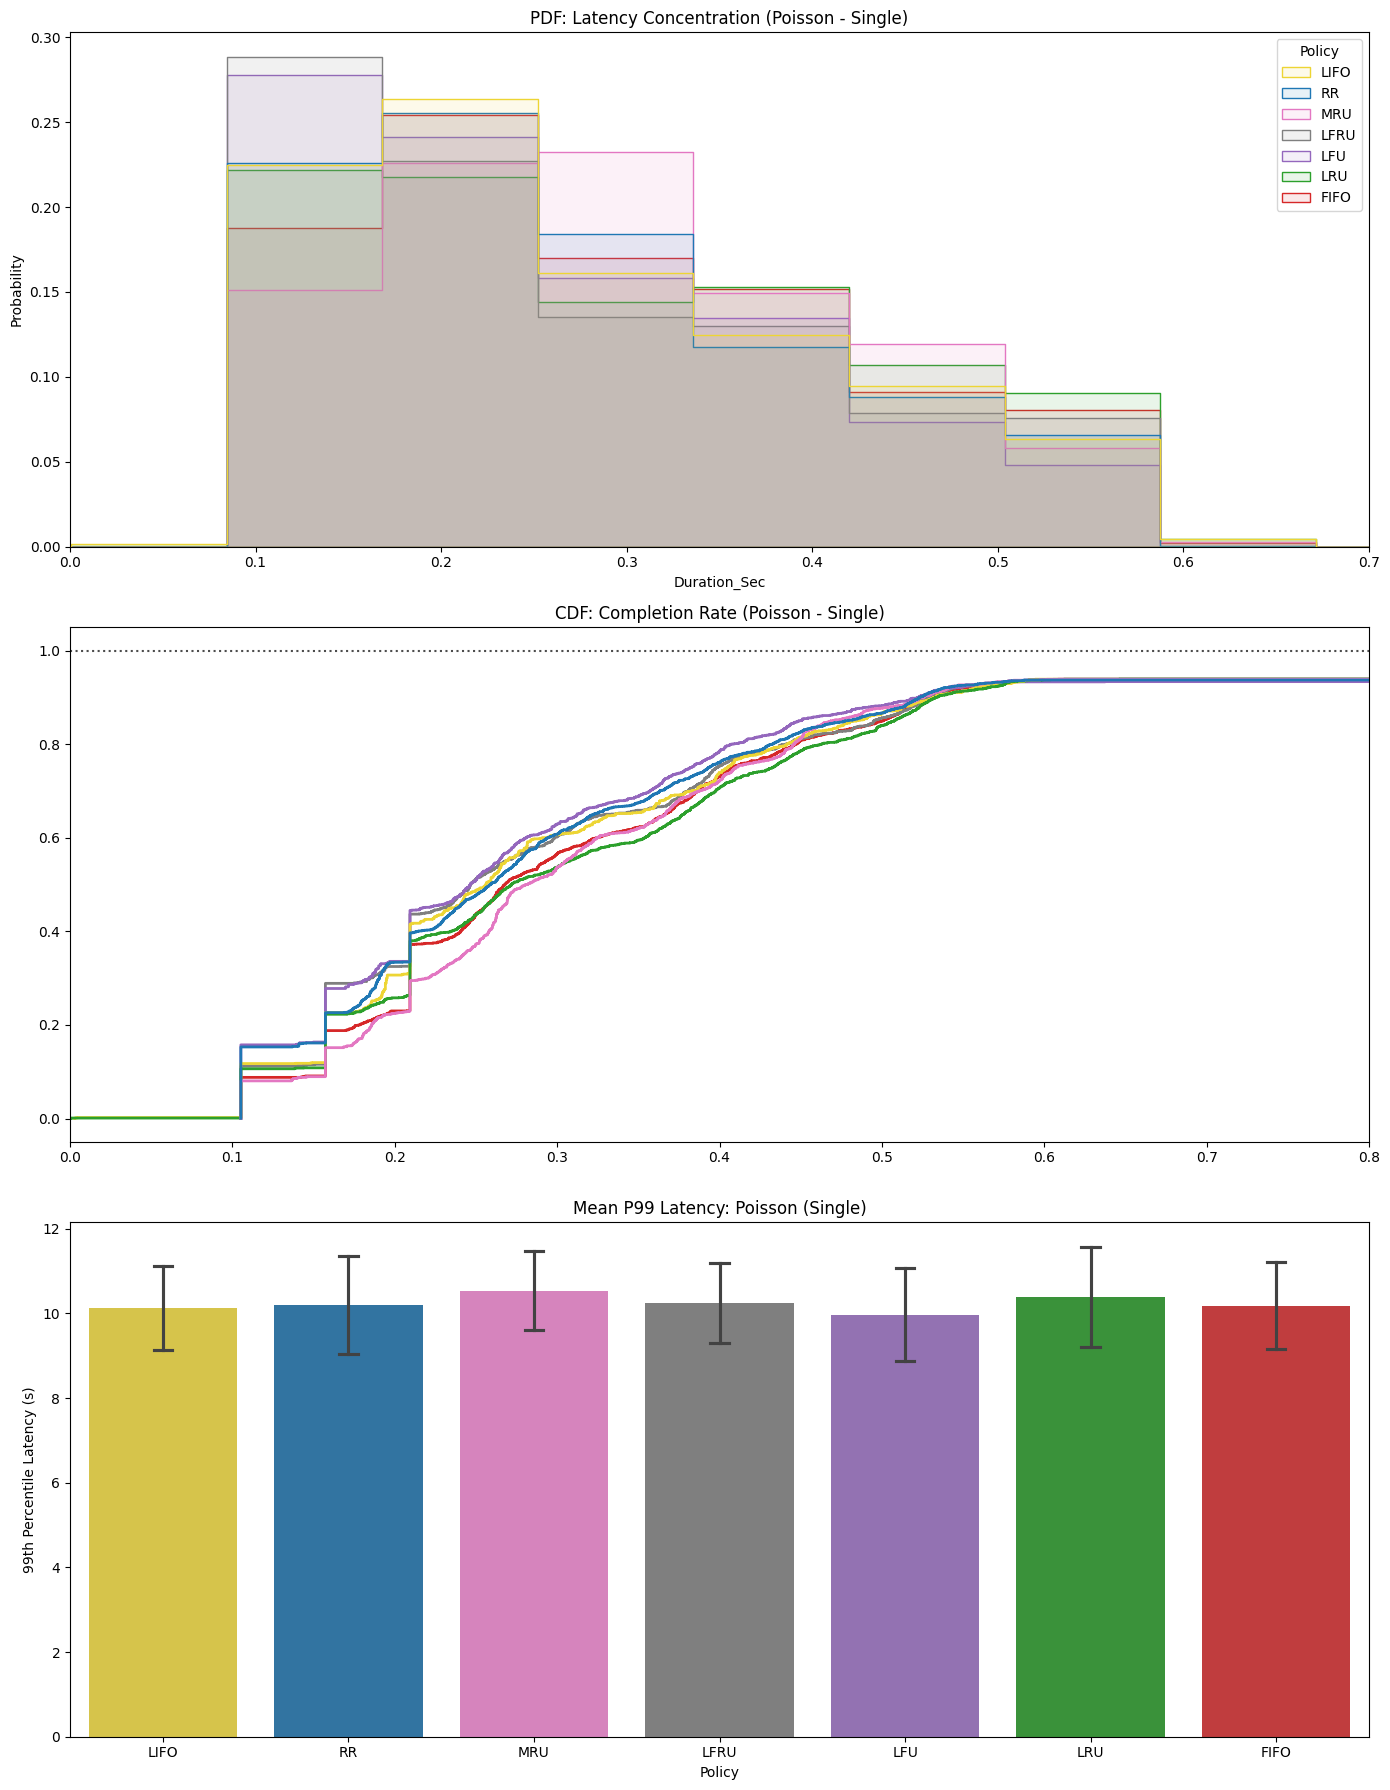

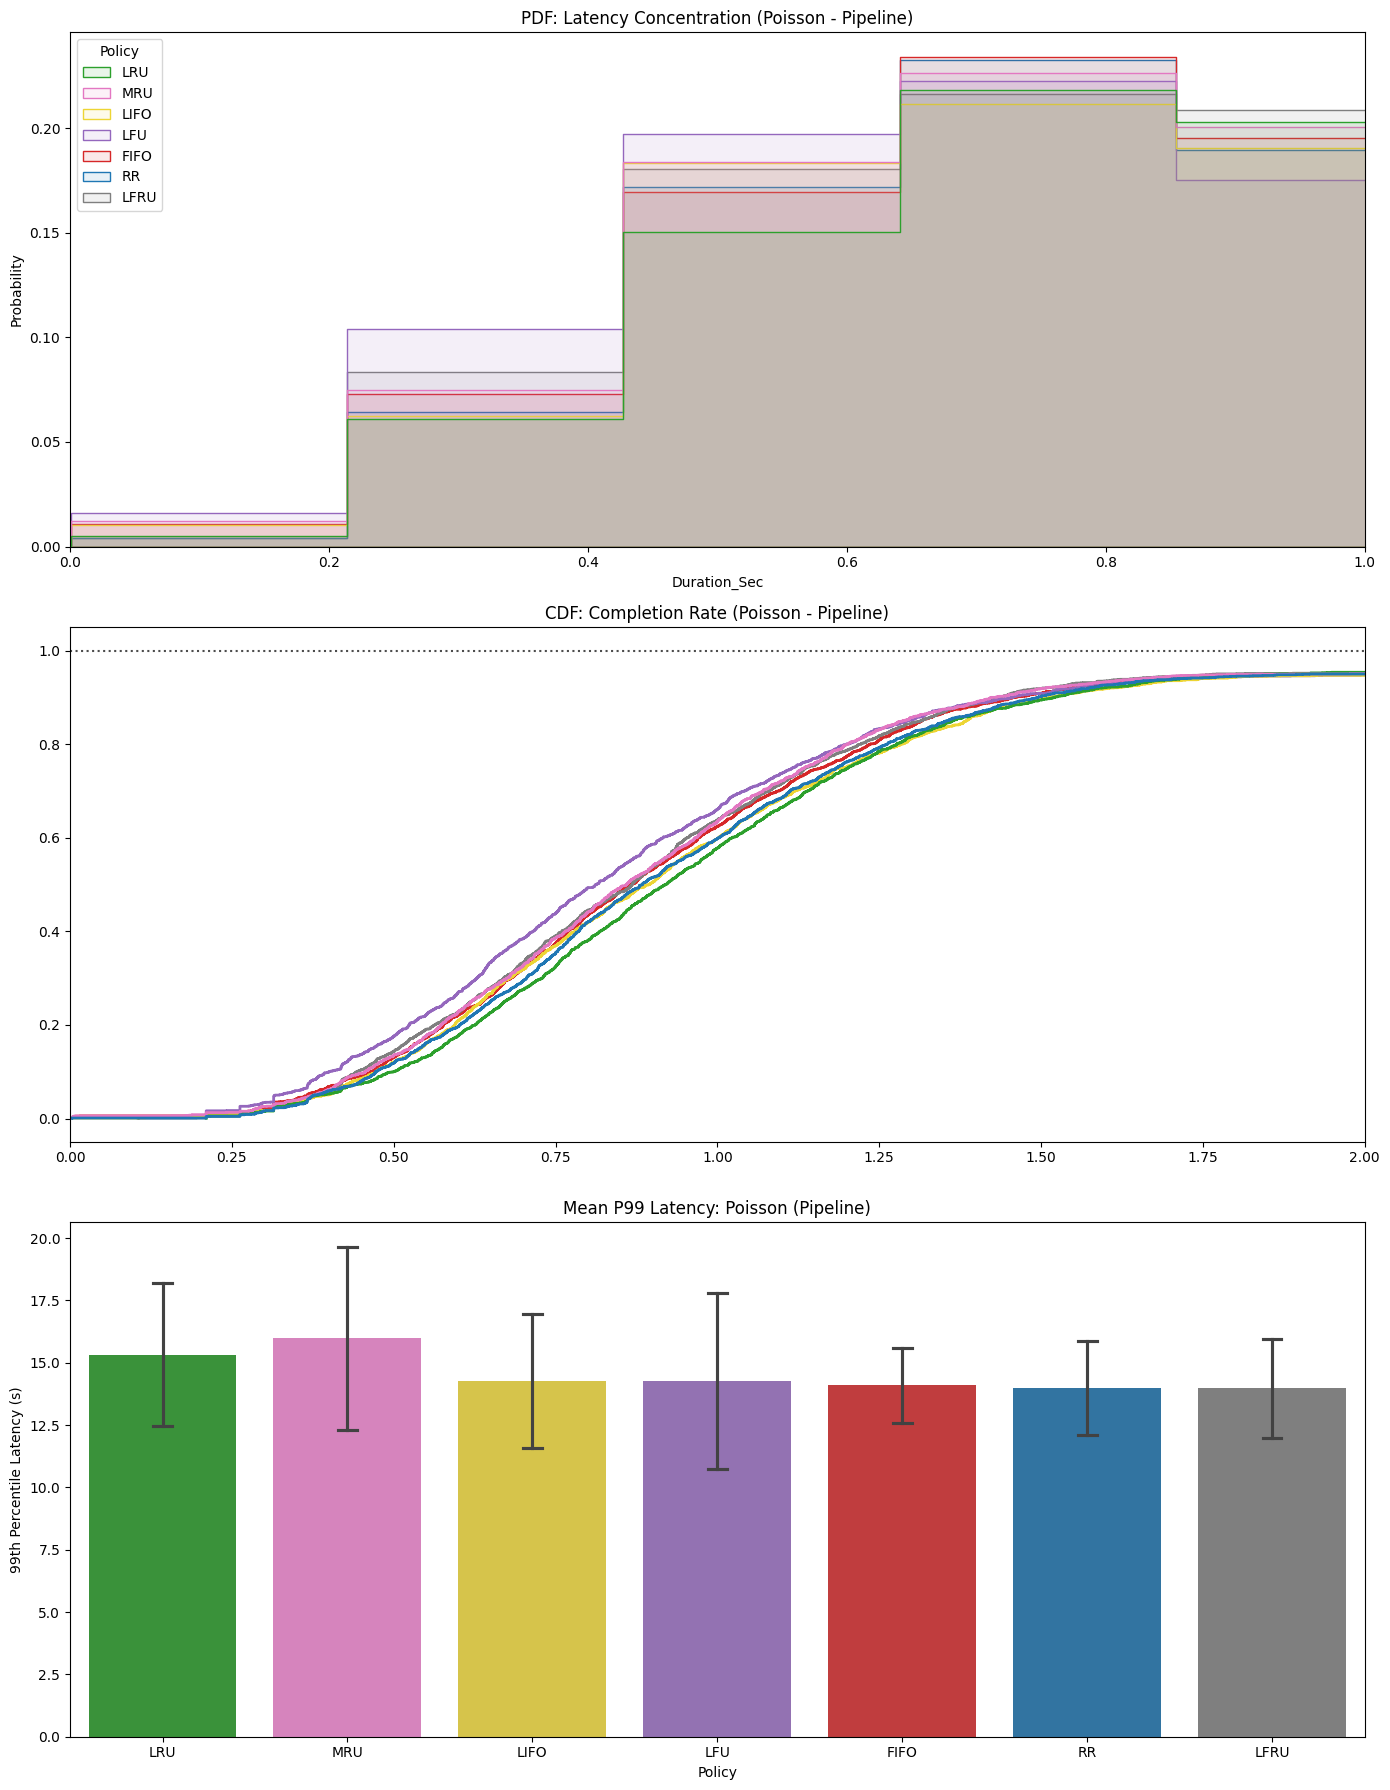

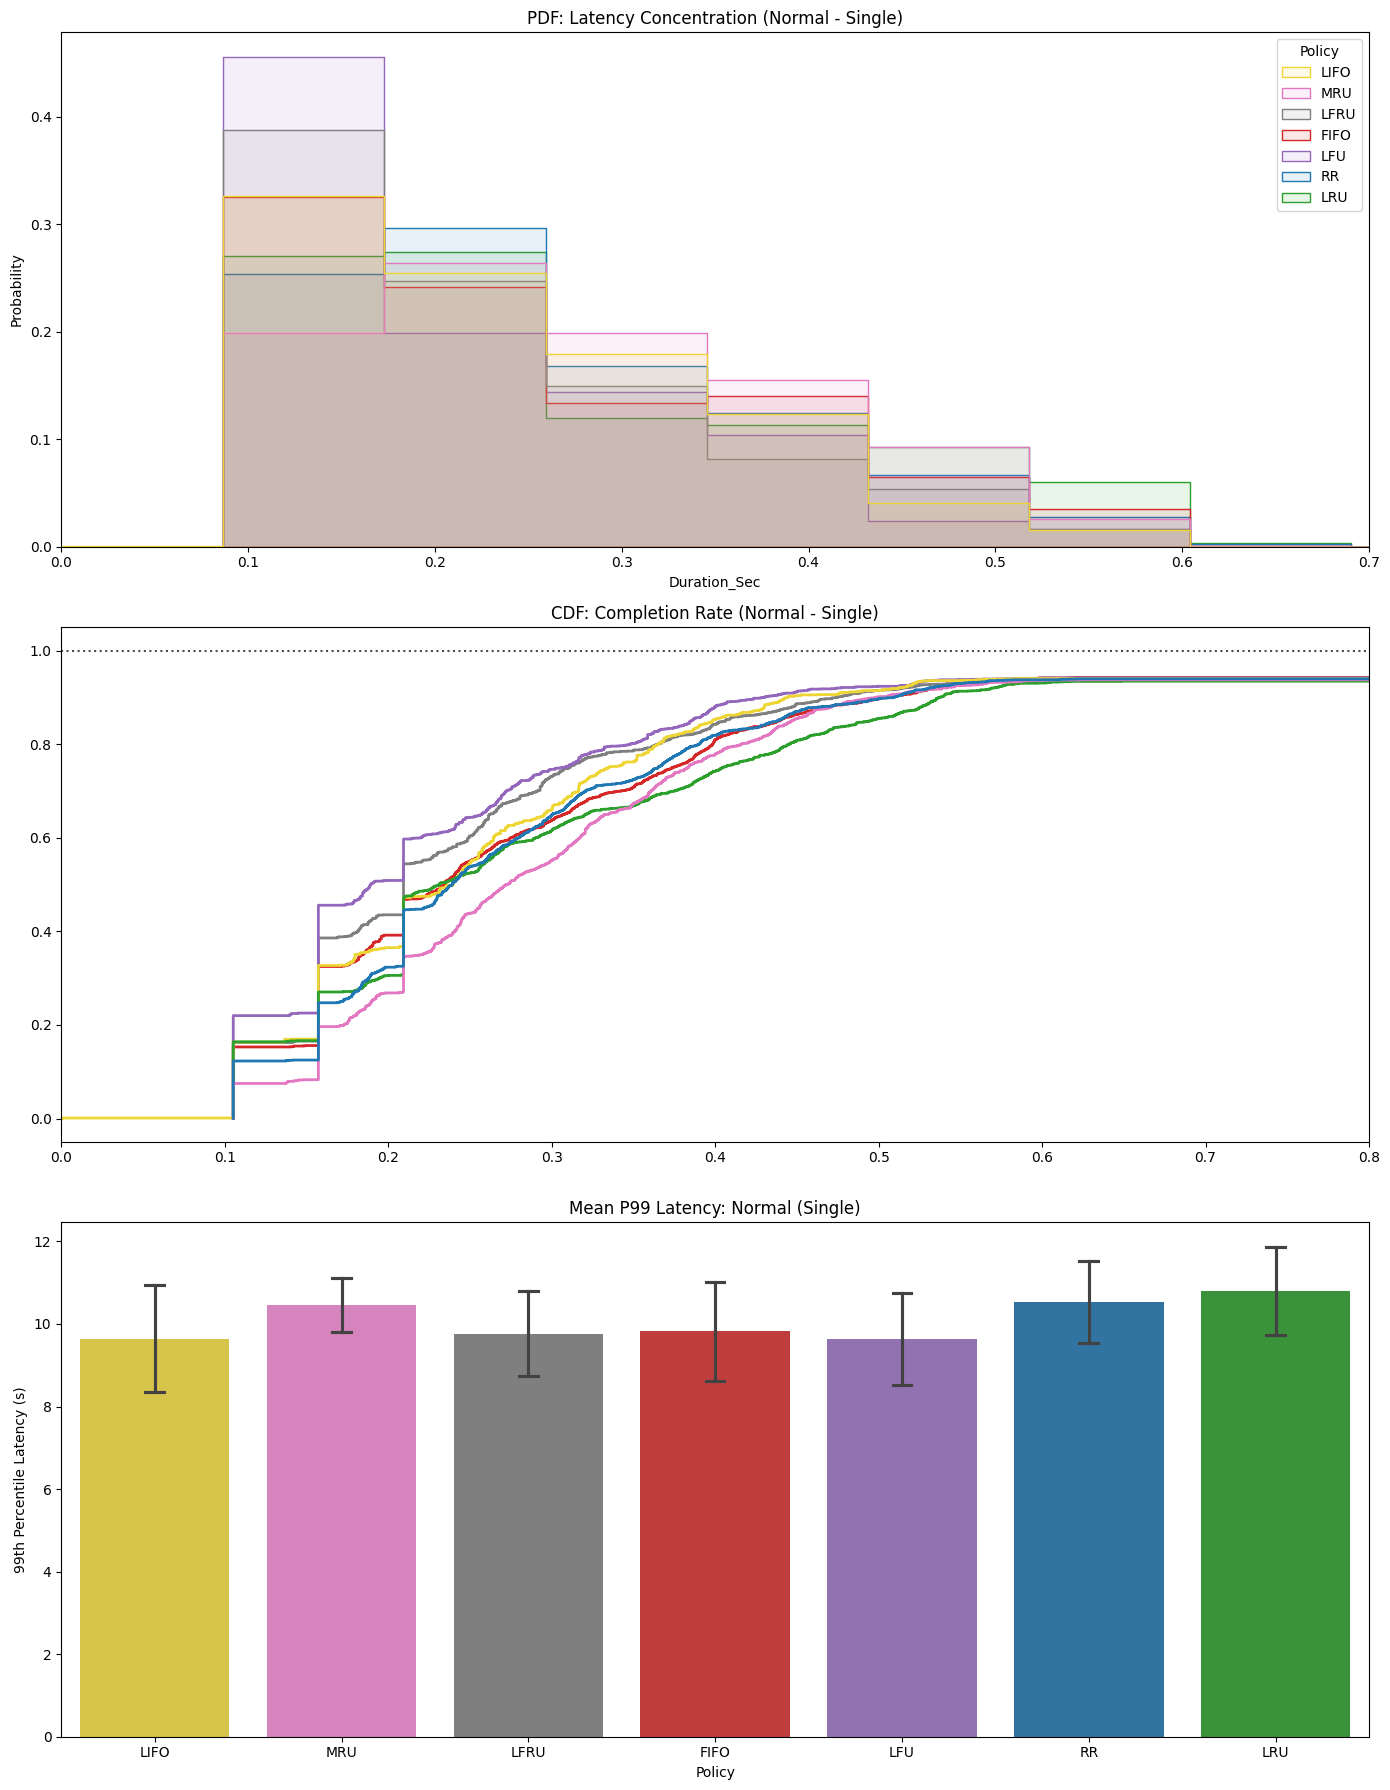

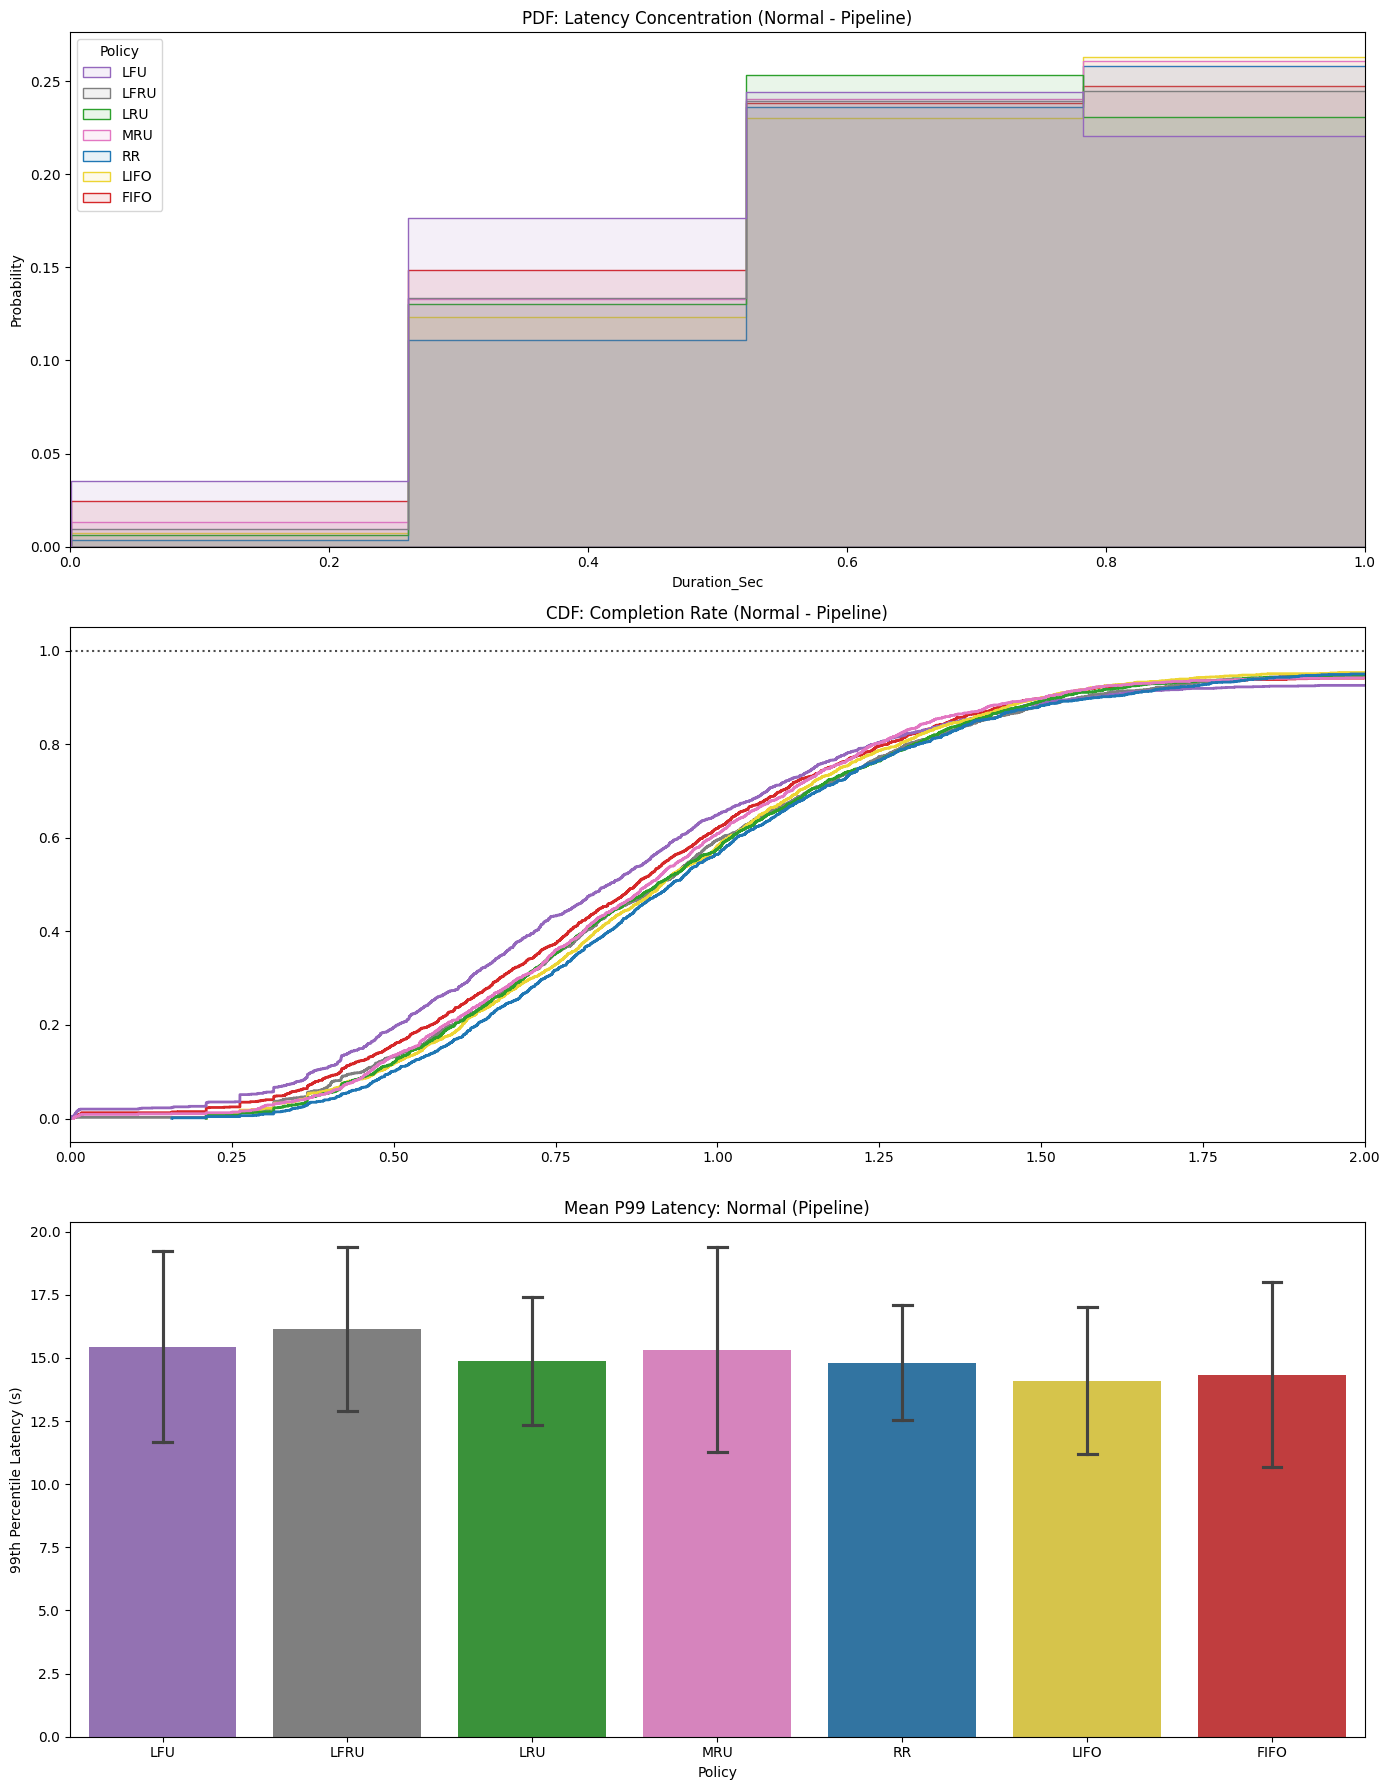

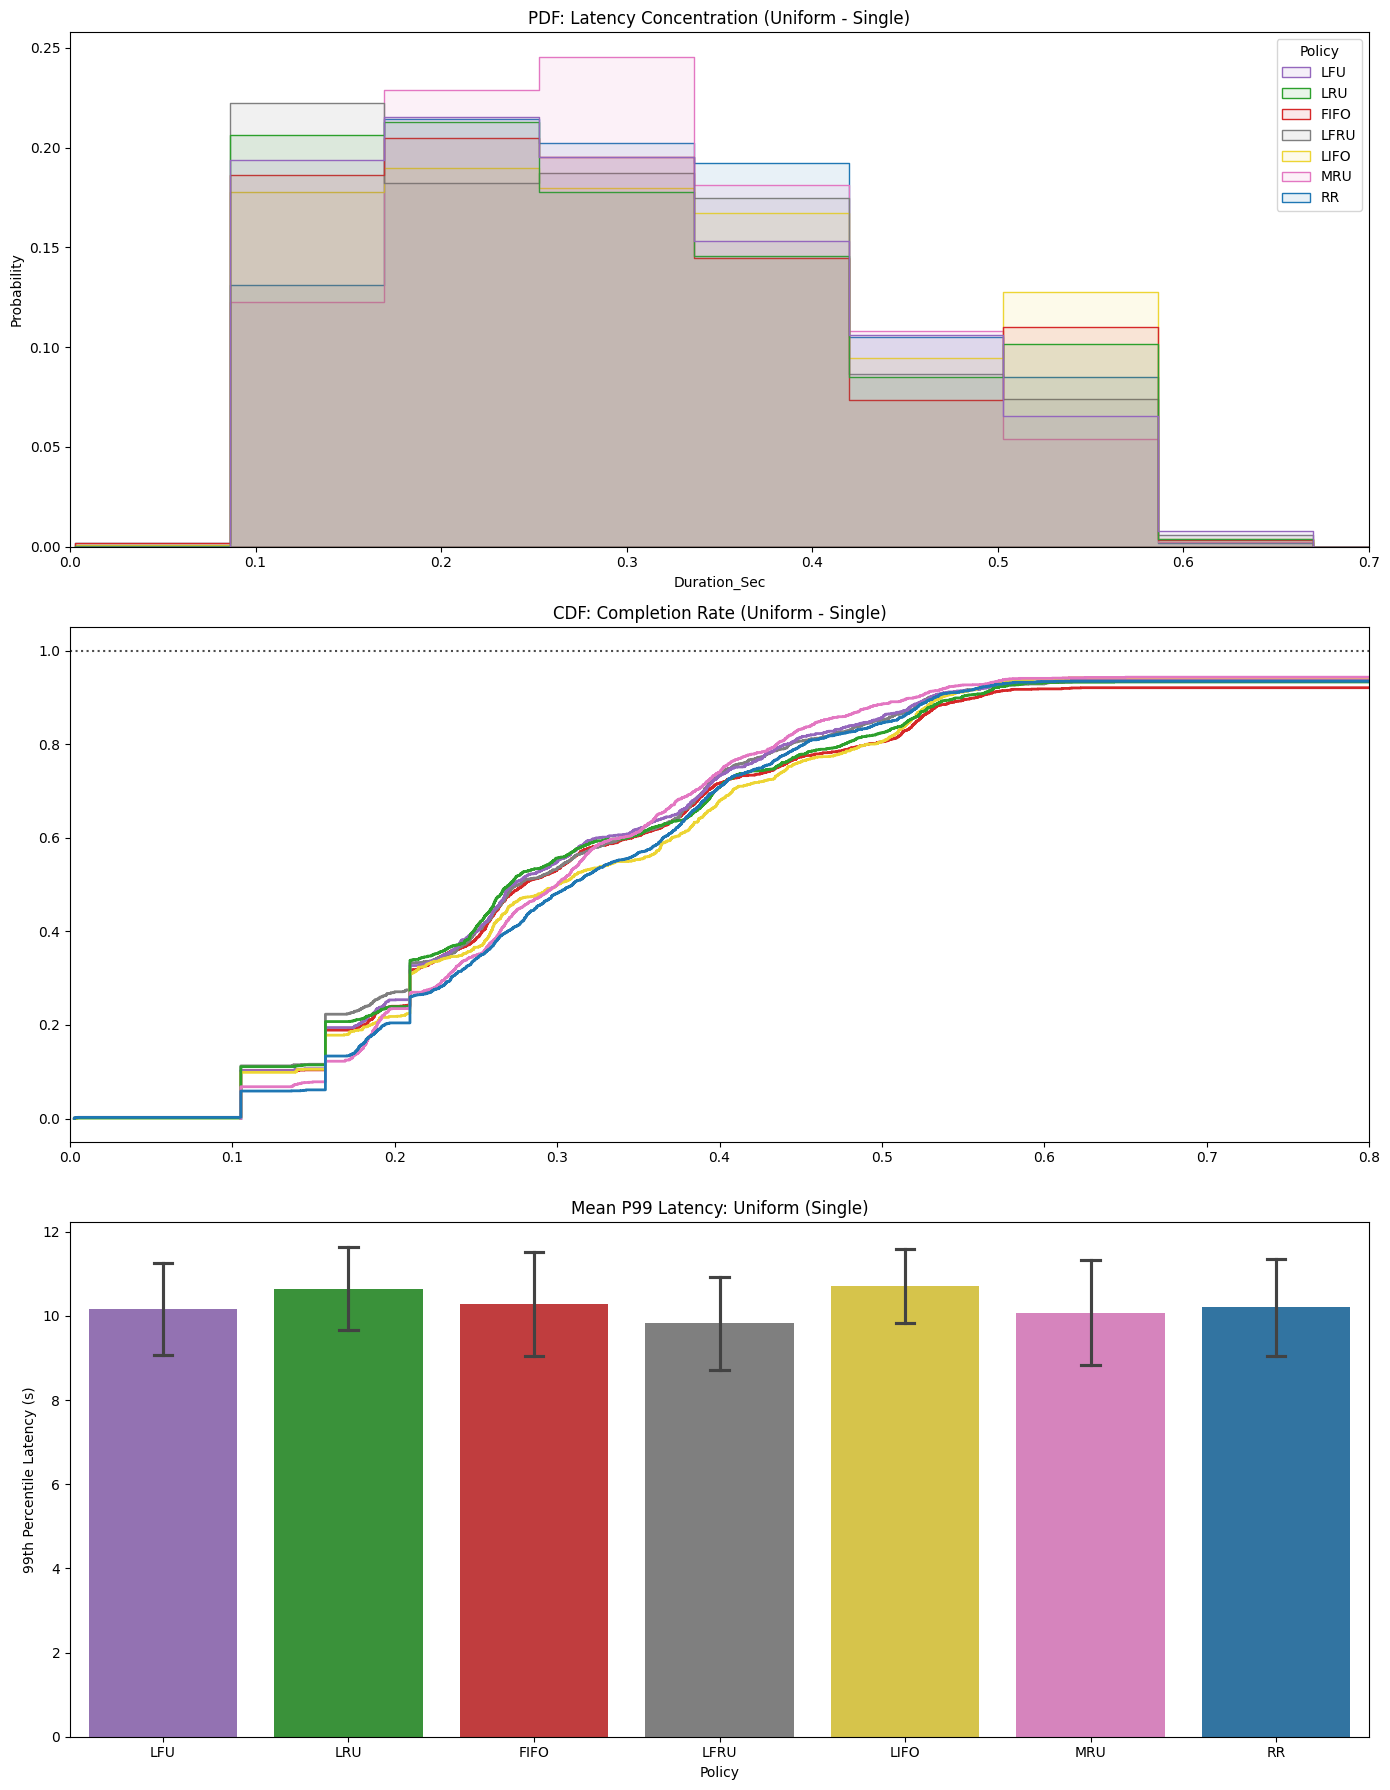

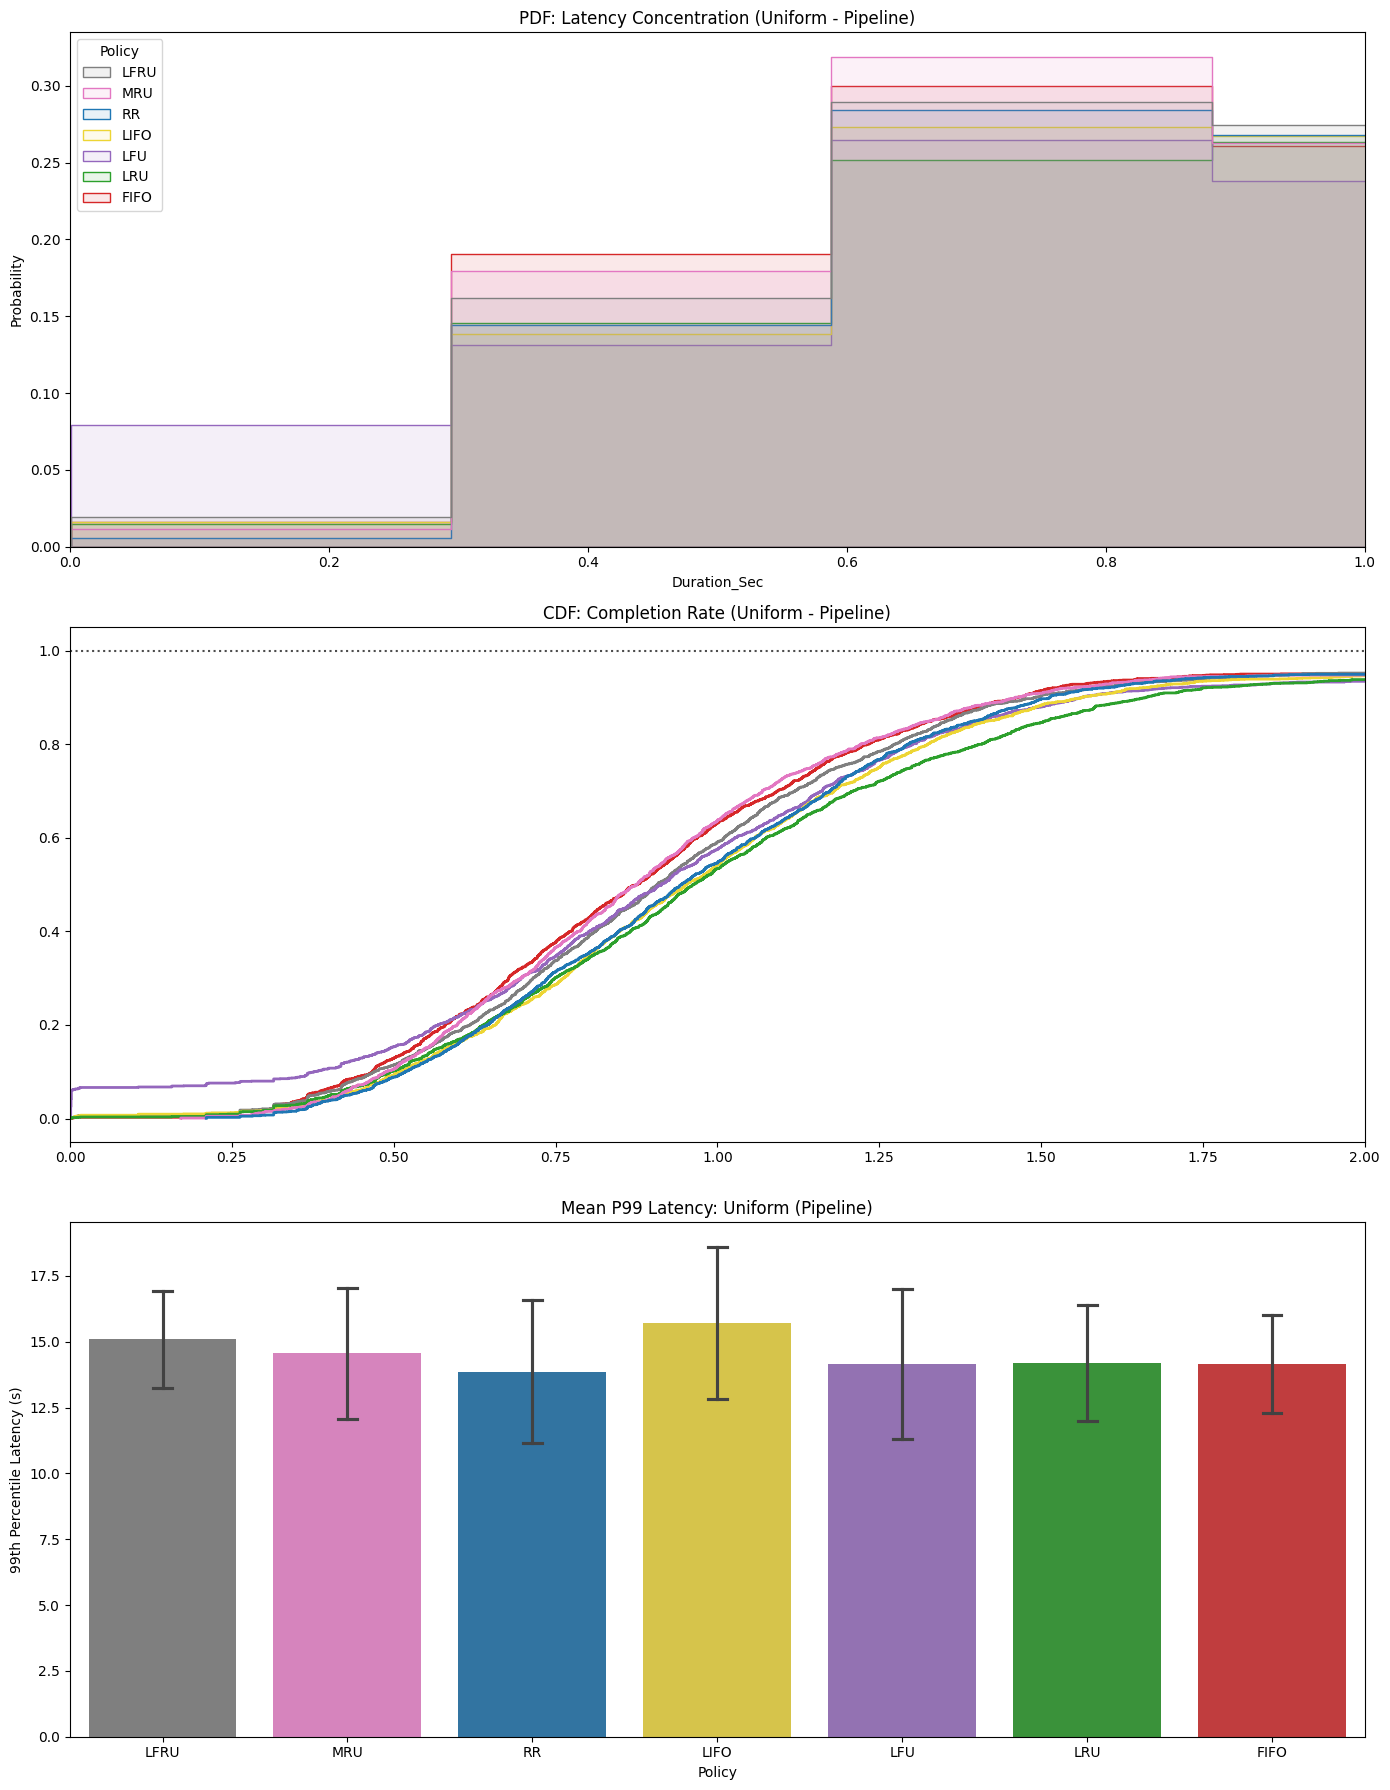

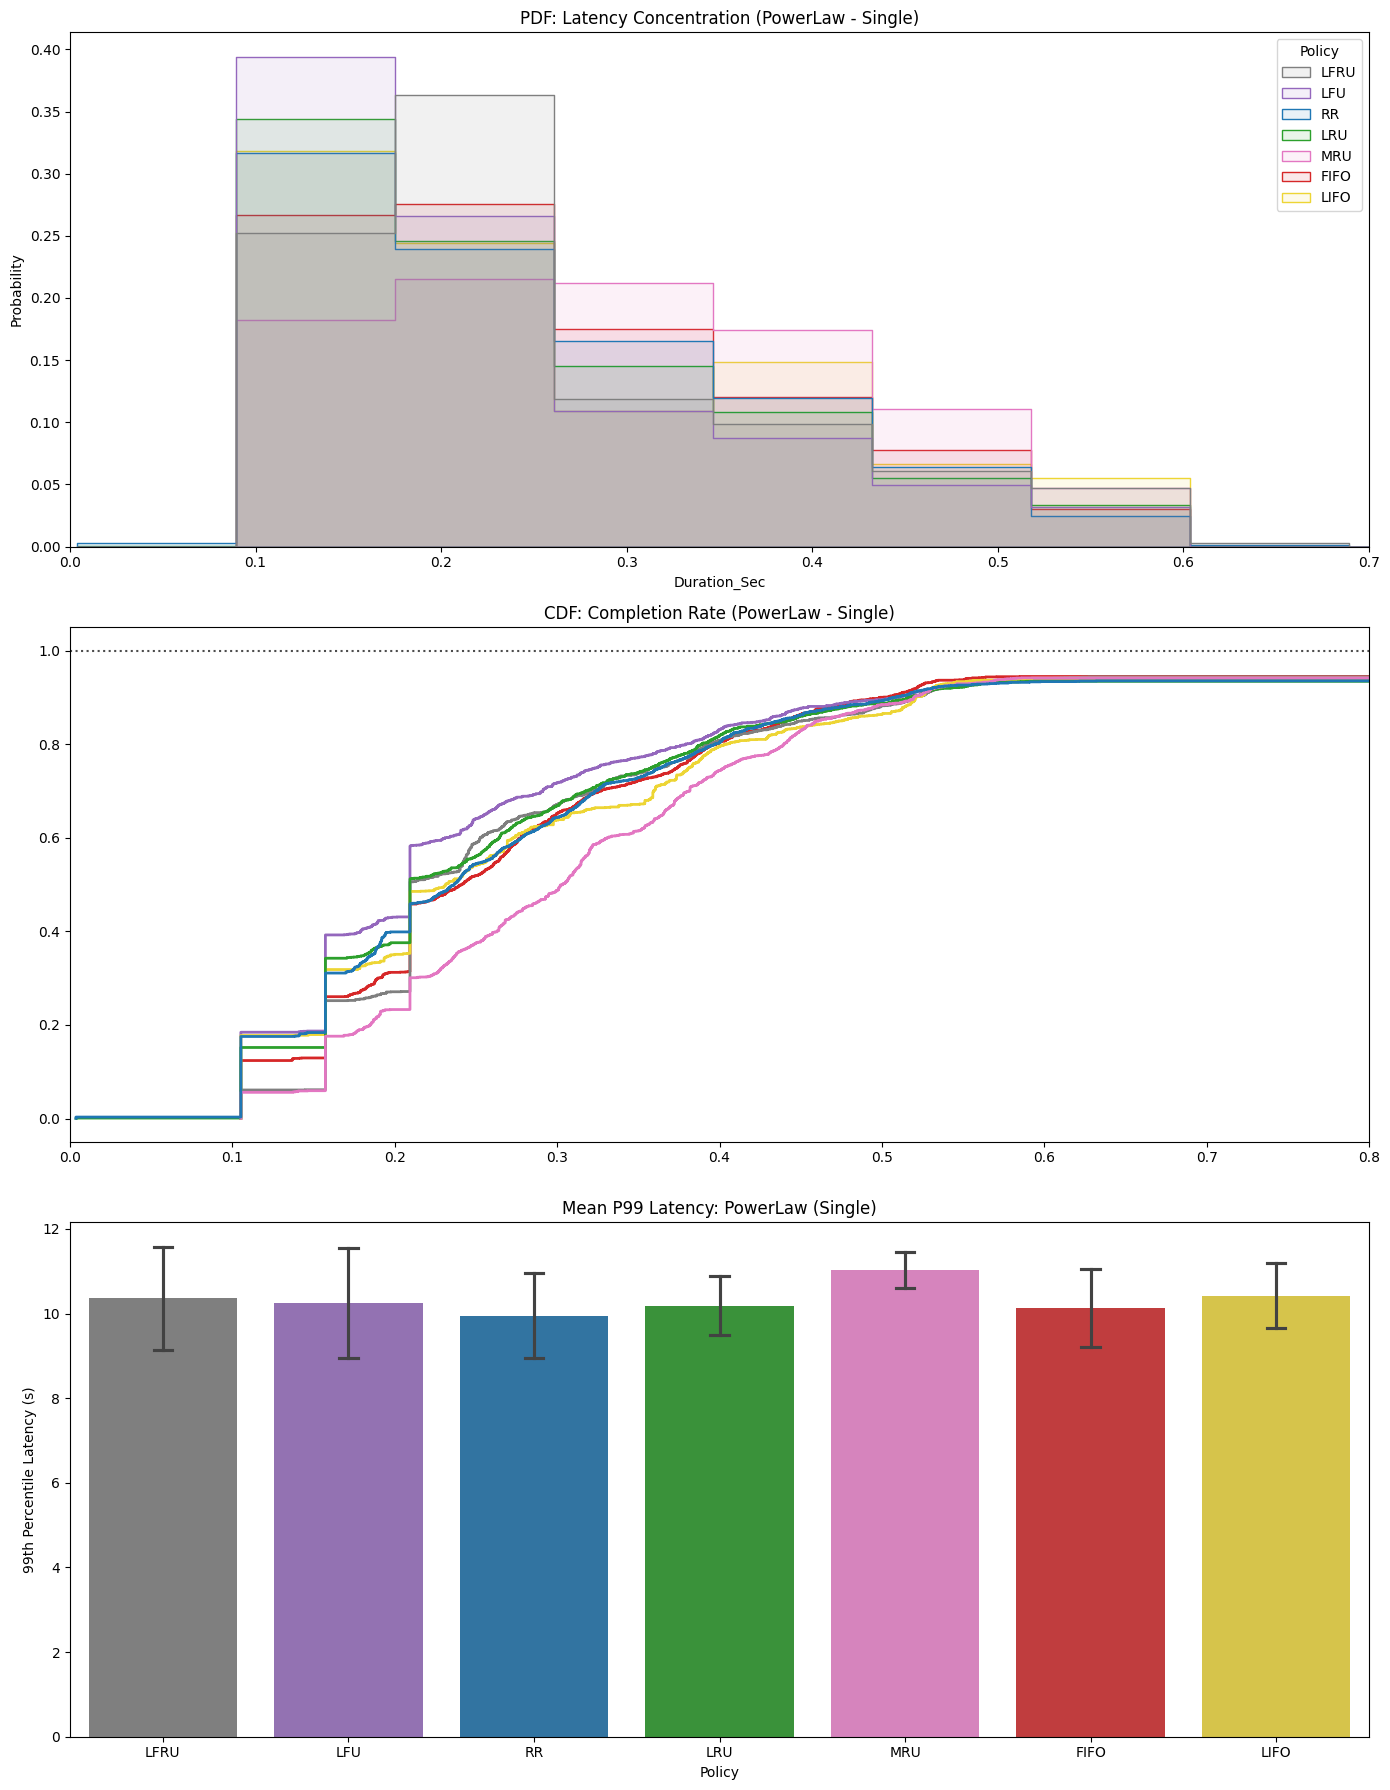

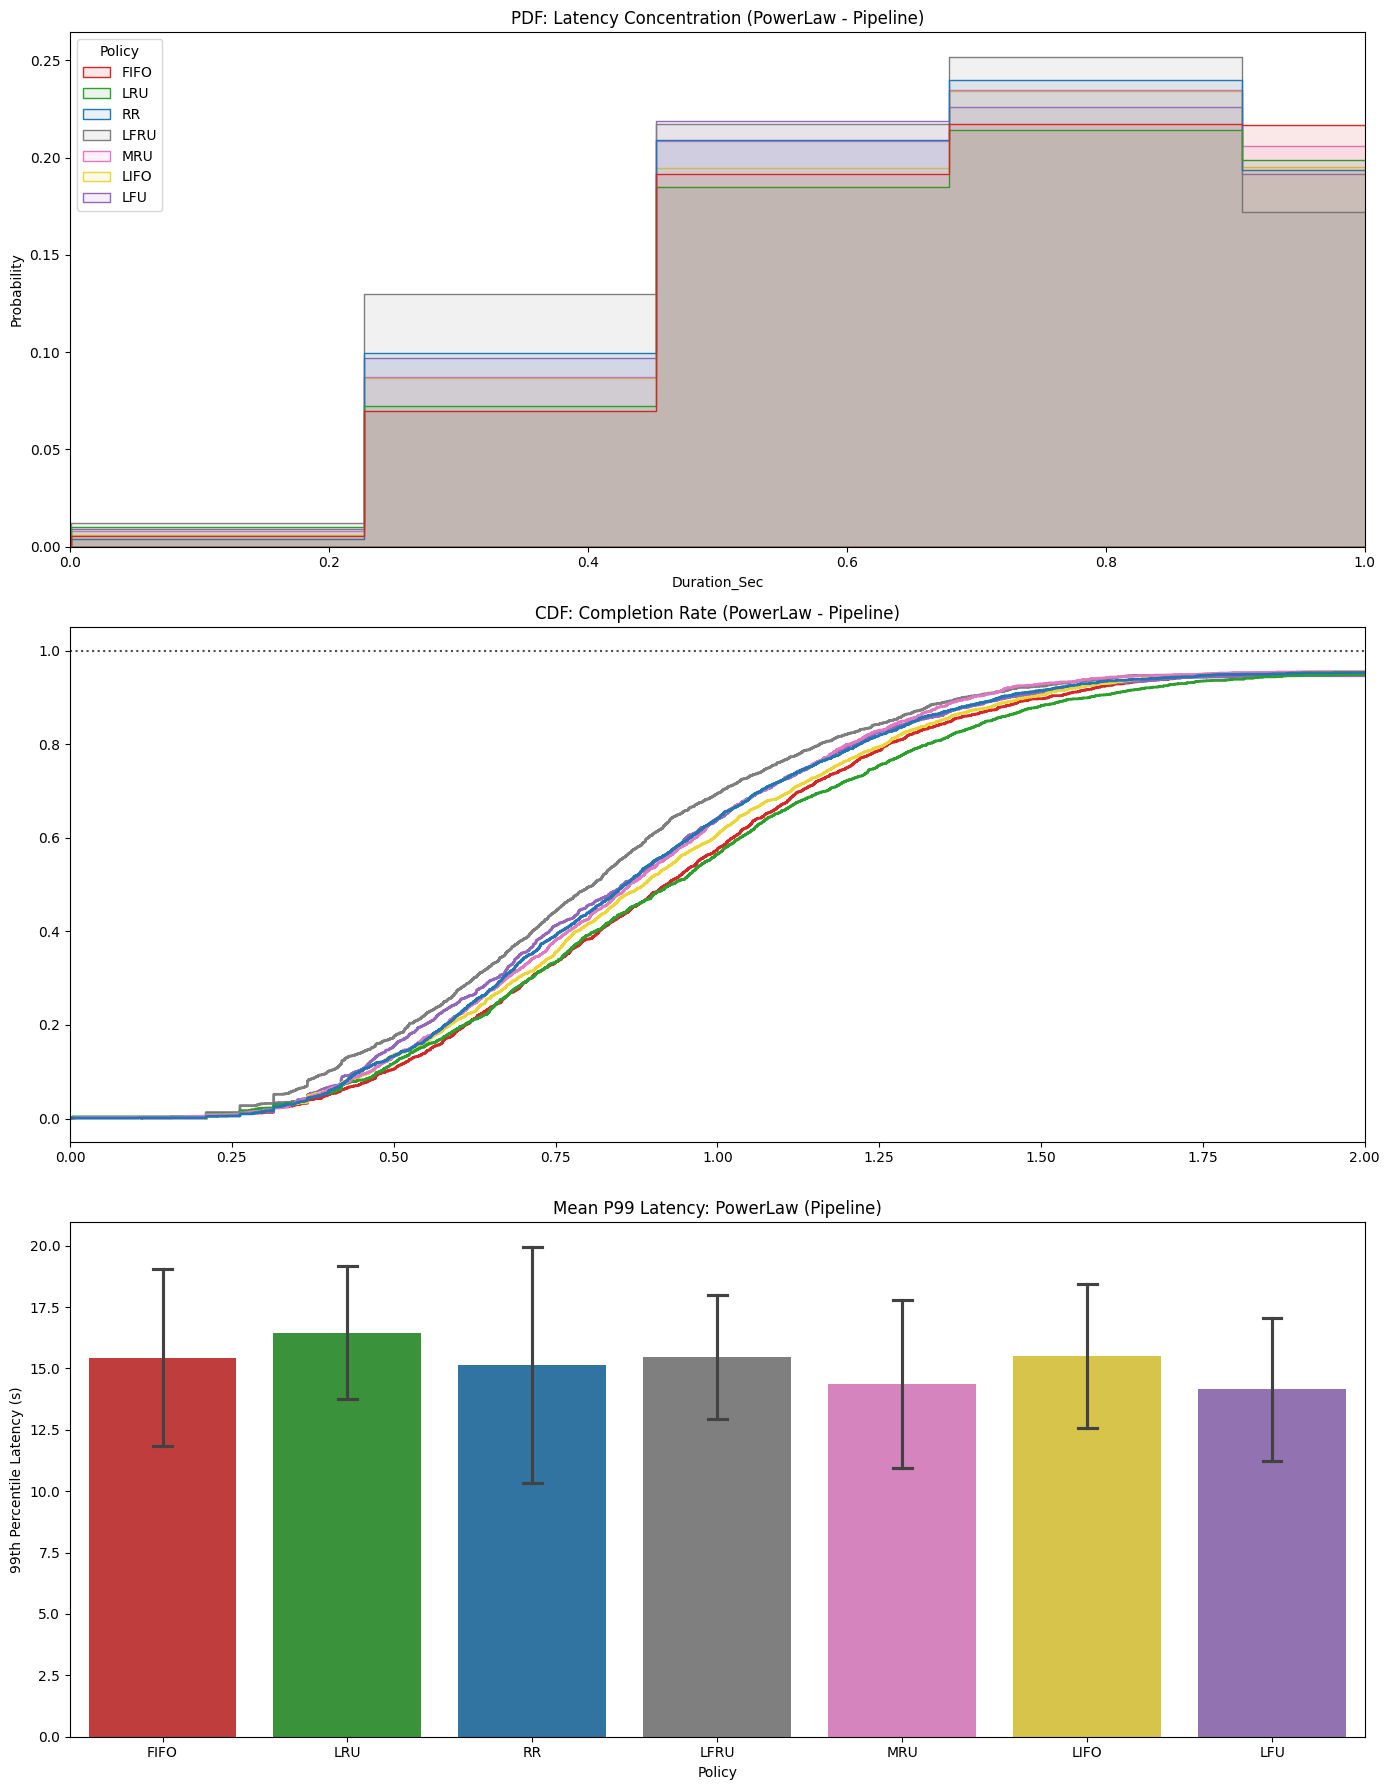

In [ ]:
POLICY_COLORS = {'LRU': '#2ca02c',
            'RR': '#1f77b4',
            'Immediate': '#ff7f0e',
            'LFU': '#9467bd',
            'FIFO': '#d62728',
            'LIFO': '#edd534',
            'MRU': '#e377c2',
            'LFRU': '#7f7f7f'
            }

from statsmodels.distributions.empirical_distribution import ECDF
def load_multi_run_results(pattern="../res/real_life/bench_*_iter*.csv"):
    all_raw_data = []      
    iteration_stats = []   
    
    files = glob.glob(pattern)
    for f in files:
        parts = os.path.basename(f).replace('.csv', '').split('_')
        # [0]bench, [1]policy, [2]dist, [3]mode, [4]cID, [5]iter
        policy, dist, mode = parts[1], parts[2], parts[3]
        iteration = parts[5].replace('iter', '')

        df = pd.read_csv(f)
        req_latencies = df.groupby('RequestID')['Duration_Sec'].sum().reset_index()
        
        req_latencies['Policy'] = policy
        req_latencies['Distribution'] = dist
        req_latencies['Mode'] = mode # New field
        all_raw_data.append(req_latencies)
        
        iteration_stats.append({
            'Policy': policy,
            'Distribution': dist,
            'Mode': mode, # New field
            'Iteration': iteration,
            'Median_Latency': req_latencies['Duration_Sec'].median(),
            'P99_Latency': req_latencies['Duration_Sec'].quantile(0.99)
        })
    
    return pd.concat(all_raw_data), pd.DataFrame(iteration_stats)

def plot_comprehensive_benchmarks(raw_data, stat_data):
    distributions = raw_data['Distribution'].unique()
    modes = raw_data['Mode'].unique()

    for dist in distributions:
        for mode in modes:
            # Filter for specific Dist and Mode (Single/Pipeline)
            raw_subset = raw_data[(raw_data['Distribution'] == dist) & (raw_data['Mode'] == mode)]
            stat_subset = stat_data[(stat_data['Distribution'] == dist) & (stat_data['Mode'] == mode)]
            
            if raw_subset.empty: continue

            fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18))
            
            # 1. PDF (Focus on concentration)
            sns.histplot(
                data=raw_subset, x='Duration_Sec', hue='Policy', palette=POLICY_COLORS,
                element="step", stat="probability", common_norm=False, bins=150, alpha=0.1, ax=ax1
            )
            # Set X-limit wider for Pipeline mode (cascading cold starts)
            max_x = 1.0 if mode == "Single" else 15.0 
            if mode == "Pipeline":
                ax1.set_xlim(0, 1.0)
            else:
                ax1.set_xlim(0, 0.7)
            ax1.set_title(f"PDF: Latency Concentration ({dist} - {mode})")

            # 2. CDF (Tail Analysis)
            for policy in sorted(raw_subset['Policy'].unique()):
                p_data = raw_subset[raw_subset['Policy'] == policy]['Duration_Sec']
                ecdf = ECDF(p_data)
                ax2.step(ecdf.x, ecdf.y, label=policy, color=POLICY_COLORS.get(policy), linewidth=2)
            
            ax2.axhline(y=1.0, color='black', linestyle=':', alpha=0.7)
            if mode == "Pipeline":
                ax2.set_xlim(0, 2.0)
            else:
                ax2.set_xlim(0, 0.8) # Notice the tail going toward your 12s limit
            ax2.set_title(f"CDF: Completion Rate ({dist} - {mode})")

            # 3. BAR PLOT (Representative P99)
            # Using P99 here instead of Median because it's more sensitive to pipeline fan-out
            sns.barplot(
                data=stat_subset, x='Policy', y='P99_Latency', 
                palette=POLICY_COLORS, errorbar='sd', capsize=.1, ax=ax3
            )
            ax3.set_title(f"Mean P99 Latency: {dist} ({mode})")
            ax3.set_ylabel("99th Percentile Latency (s)")
            
            plt.tight_layout()
            plt.show()

# Load and run
raw_data, stat_data = load_multi_run_results()
plot_comprehensive_benchmarks(raw_data, stat_data)

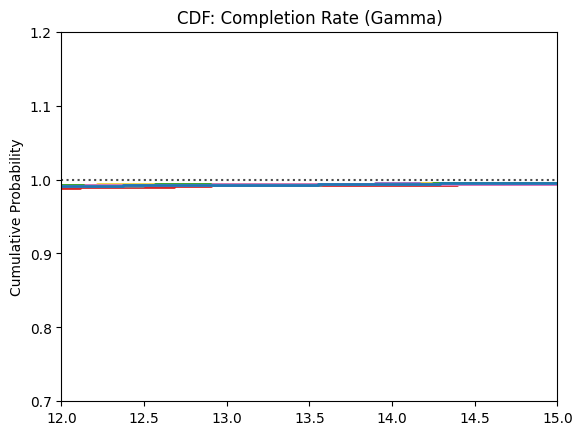

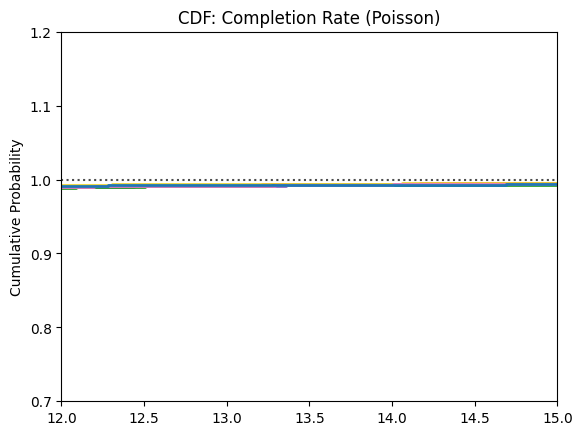

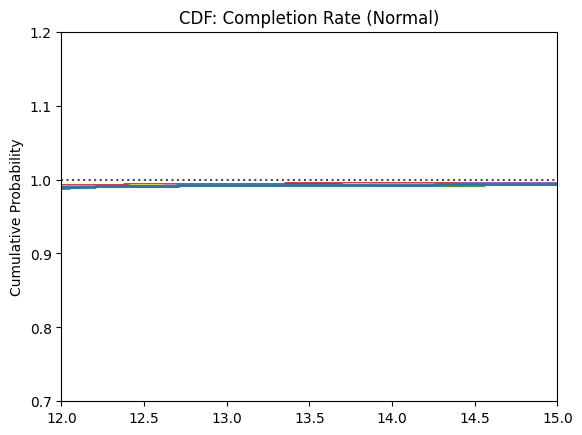

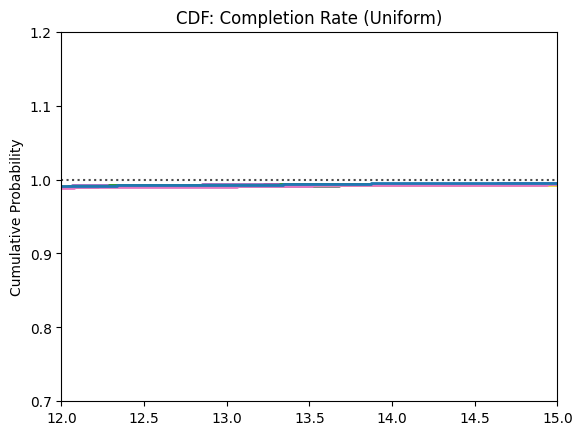

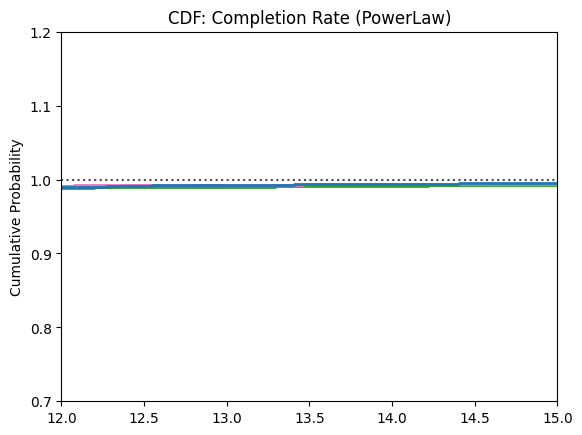

In [ ]:
def plot_comprehensive_benchmarks(raw_data, stat_data):
    distributions = raw_data['Distribution'].unique()

    for dist in distributions:
        # Filter data for this distribution
        raw_subset = raw_data[raw_data['Distribution'] == dist]
        stat_subset = stat_data[stat_data['Distribution'] == dist]
        
        # Create 3 subplots: PDF, CDF, and Representative Bar Plot
        fig, ax1 = plt.subplots()
        
        for policy in sorted(raw_subset['Policy'].unique()):
            p_data = raw_subset[raw_subset['Policy'] == policy]['Duration_Sec']
            ecdf = ECDF(p_data)
            ax1.step(ecdf.x, ecdf.y, label=policy, color=POLICY_COLORS.get(policy), linewidth=2)
        
        ax1.set_xlim(12.0, 15.0)
        ax1.axhline(y=1.0, color='black', linestyle=':', alpha=0.7)
        ax1.set_ylim(0.7, 1.2)
        
        ax1.set_title(f"CDF: Completion Rate ({dist})")
        ax1.set_ylabel("Cumulative Probability")

        
# Run the updated plots
plot_comprehensive_benchmarks(raw_data, stat_data)